# Flow-Based Signals - OFI, Microprice, Tick-Through

Our A1-A6 signals measure the **state** of the order book (structure, distribution, depth). They miss the **flow** - the actual movement of orders into and out of the book. Flow-based signals have been shown to deliver IC = 0.2-0.5 on liquid instruments, vs ~0.07 for our current composite.

**Signals tested here:**
1. **OFI (top-of-book)** - Cont, Kukanov & Stoikov 2014. Direct measurement of buy/sell pressure from L1 depth changes.
2. **OFI (multi-level)** - Kolm et al. 2021. Extends OFI across the top N levels with decay weights.
3. **Microprice deviation** - Stoikov 2018. Queue-weighted midprice, captures top-of-book imbalance.
4. **Tick-through events** - discrete signal when midprice moves multiple ticks in one packet (indicates aggressive informed orders).
5. **L1 quantity stability** - iceberg/hidden liquidity proxy: when L1 qty stays steady despite price activity, hidden flow is refilling.

**Goal:** identify which (if any) of these signals reaches IC = 0.20+ at horizons that beat NSE futures costs (~₹185 break-even directional edge per trade).

**Methodology:** same as `ic_analysis.ipynb` - Spearman rank correlation per (symbol, date), aggregated to mean IC, ICIR, and pct_pos.

## Section 1 - Setup

In [1]:
import sys
sys.path.insert(0, "/Users/krishhiv/Desktop/argus-alpha-research")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from research.data.load_data import load_depth, DATA_ROOT
from research.features.depth_features import add_all_features
from research.backtester.walkforward import _build_inventory

TICK_SIZE = 0.05
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## Section 2 - Signal Implementations

Each signal is a pure function: takes a depth DataFrame, returns it with new columns added. Memory-light - no copies of the full depth, just adds the new columns in place.

### 2.1 - OFI top-of-book

$$e_b(t) = \begin{cases} q_b(t) & p_b(t) > p_b(t-1) \\ -q_b(t-1) & p_b(t) < p_b(t-1) \\ q_b(t) - q_b(t-1) & p_b(t) = p_b(t-1) \end{cases}$$

and symmetrically for ask side (with sign flip - lower ask = bullish). $\text{OFI} = e_b - e_a$.

In [2]:
def add_ofi_l1(df):
    bid_p = df["bid_price_01"].to_numpy()
    bid_q = df["bid_qty_01"].to_numpy()
    ask_p = df["ask_price_01"].to_numpy()
    ask_q = df["ask_qty_01"].to_numpy()

    bp_prev = np.roll(bid_p, 1); bq_prev = np.roll(bid_q, 1)
    ap_prev = np.roll(ask_p, 1); aq_prev = np.roll(ask_q, 1)

    e_b = np.where(bid_p > bp_prev, bid_q,
          np.where(bid_p < bp_prev, -bq_prev, bid_q - bq_prev))
    e_a = np.where(ask_p < ap_prev, ask_q,
          np.where(ask_p > ap_prev, -aq_prev, ask_q - aq_prev))

    ofi = e_b - e_a
    ofi[0] = 0  # first packet has no diff

    out = df.copy()
    out["ofi_l1"] = ofi
    return out

### 2.2 - Multi-level OFI

Sum the OFI across the top $K$ levels, weighting by inverse depth (L1 matters most):

$$\text{OFI}_{ml} = \sum_{k=1}^{K} w_k \cdot (e_b^{(k)} - e_a^{(k)}), \quad w_k = \rho^{k-1}$$

Default: $K=10$, $\rho=0.5$ → L1 weighted 1.0, L2 weighted 0.5, ..., L10 weighted ≈0.002.

In [3]:
def add_ofi_multilevel(df, n_levels=10, decay=0.5):
    ofi_total = np.zeros(len(df))

    for k in range(1, n_levels + 1):
        weight = decay ** (k - 1)
        bp = df[f"bid_price_{k:02d}"].to_numpy()
        bq = df[f"bid_qty_{k:02d}"].to_numpy()
        ap = df[f"ask_price_{k:02d}"].to_numpy()
        aq = df[f"ask_qty_{k:02d}"].to_numpy()

        bp_prev = np.roll(bp, 1); bq_prev = np.roll(bq, 1)
        ap_prev = np.roll(ap, 1); aq_prev = np.roll(aq, 1)

        e_b = np.where(bp > bp_prev, bq, np.where(bp < bp_prev, -bq_prev, bq - bq_prev))
        e_a = np.where(ap < ap_prev, aq, np.where(ap > ap_prev, -aq_prev, aq - aq_prev))

        ofi_total += weight * (e_b - e_a)

    ofi_total[0] = 0

    out = df.copy()
    out["ofi_ml"] = ofi_total
    return out

### 2.3 - Microprice

$$\text{microprice} = \frac{p_b \cdot q_a + p_a \cdot q_b}{q_a + q_b}$$

When ask qty is small (depleted), microprice is pulled toward the ask → expect upward move. `micro_deviation = microprice - midprice` is the directional bias.

In [4]:
def add_microprice(df):
    bid_p = df["bid_price_01"].to_numpy()
    bid_q = df["bid_qty_01"].to_numpy()
    ask_p = df["ask_price_01"].to_numpy()
    ask_q = df["ask_qty_01"].to_numpy()

    total_q = bid_q + ask_q
    micro = (bid_p * ask_q + ask_p * bid_q) / (total_q + 1e-9)

    out = df.copy()
    out["microprice"] = micro
    out["micro_deviation"] = micro - df["midprice"].to_numpy()
    return out

### 2.4 - Tick-Through Events

When the midprice moves ≥2 ticks in a single packet, an aggressive informed order consumed multiple levels. Signal is $\pm 1$ for the direction of the move, 0 otherwise. Often followed by momentum continuation.

Also compute `tick_through_50` = rolling sum of signed tick-throughs over the last 50 packets (captures recent informed flow direction).

In [5]:
def add_tick_through(df, threshold_ticks=2):
    mid = df["midprice"].to_numpy()
    move = mid - np.roll(mid, 1)
    move[0] = 0

    tt = np.where(np.abs(move) >= threshold_ticks * TICK_SIZE, np.sign(move), 0).astype(float)

    out = df.copy()
    out["tick_through"] = tt
    out["tick_through_50"] = pd.Series(tt, index=df.index).rolling(50).sum()
    return out

### 2.5 - L1 Quantity Stability (Iceberg Proxy)

When the L1 quantity stays unusually steady despite midprice activity, hidden orders are likely refilling (iceberg). High bid stability = hidden buyer, high ask stability = hidden seller.

$$\text{stability}_b = \frac{\text{range}(\text{mid}, w)}{\text{CV}(\text{bid\_qty}, w) + \epsilon}$$

where CV = std/mean (coefficient of variation), $w$ = window size.

In [6]:
def add_l1_stability(df, window=20):
    bid_q = df["bid_qty_01"]
    ask_q = df["ask_qty_01"]
    mid   = df["midprice"]

    mid_range_ticks = (mid.rolling(window).max() - mid.rolling(window).min()) / TICK_SIZE
    bid_cv = bid_q.rolling(window).std() / (bid_q.rolling(window).mean() + 1e-9)
    ask_cv = ask_q.rolling(window).std() / (ask_q.rolling(window).mean() + 1e-9)

    bid_stab = mid_range_ticks / (bid_cv + 1e-3)
    ask_stab = mid_range_ticks / (ask_cv + 1e-3)

    out = df.copy()
    out["l1_stab_bid"] = bid_stab
    out["l1_stab_ask"] = ask_stab
    out["l1_stab_signal"] = bid_stab - ask_stab
    return out

In [7]:
def add_flow_features(df):
    df = add_ofi_l1(df)
    df = add_ofi_multilevel(df)
    df = add_microprice(df)
    df = add_tick_through(df)
    df = add_l1_stability(df)
    return df

FLOW_SIGNALS = ["ofi_l1", "ofi_ml", "micro_deviation", "tick_through", "tick_through_50", "l1_stab_signal"]

## Section 3 - Exploration on One Session

Load HDFCBANK on a recent day, apply all flow features, and inspect.

In [8]:
sample_path = sorted(DATA_ROOT.glob("trading_date=2026-05-22/symbol=HDFCBANK*/compacted-*.parquet"))[0]
df = load_depth("HDFCBANK", "2026-05-22", session_filter=True, path=sample_path)
df = add_flow_features(df)

print(f"Rows: {len(df):,}")
print(f"Time range: {df['ts_ist'].iloc[0]}  →  {df['ts_ist'].iloc[-1]}")
print(f"Midprice range: {df['midprice'].min():.2f}  →  {df['midprice'].max():.2f}")
print()
df[FLOW_SIGNALS].describe()

Rows: 92,167
Time range: 2026-05-22 09:20:00.098819  →  2026-05-22 15:24:59.899274
Midprice range: 764.85  →  776.85



,ofi_l1,ofi_ml,micro_deviation,tick_through,tick_through_50,l1_stab_signal
count,92167.0000,92167.0000,92167.0000,92167.0000,92118.0000,92148.0000
mean,-10.4072,-29.5872,-0.0127,0.0011,0.0528,166.9983
std,1511.2405,3077.2292,0.0649,0.1538,0.9083,878.5476
min,-101200.0000,-104562.3047,-0.3500,-1.0000,-5.0000,-8482.9284
25%,0.0000,-183.6914,-0.0500,0.0000,0.0000,-1.1802
50%,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0976
75%,0.0000,140.7227,0.0250,0.0000,0.0000,4.1605
max,158950.0000,163440.2344,0.2933,1.0000,6.0000,12992.6185


### 3.1 - Distributions

Are the signals zero-centered? Heavy-tailed? Skewed?

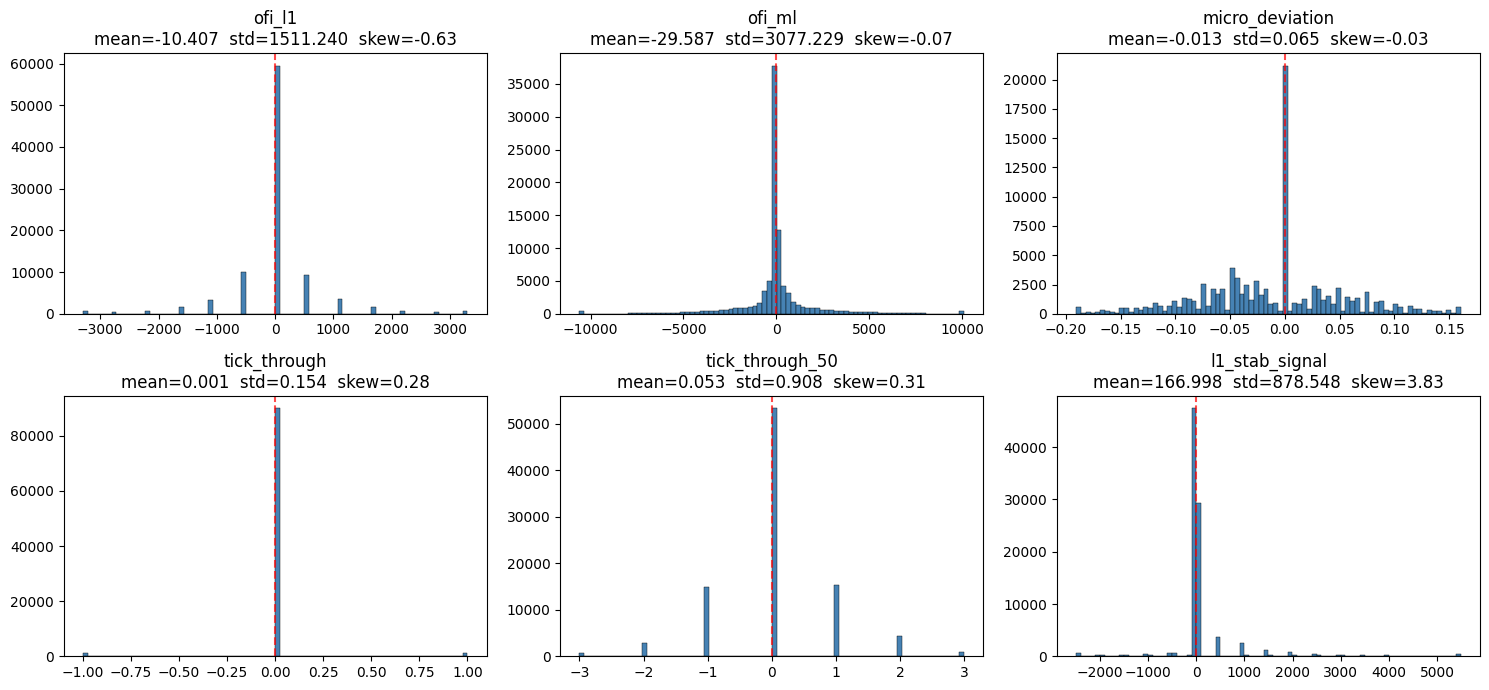

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, sig in zip(axes.flat, FLOW_SIGNALS):
    data = df[sig].dropna()
    # Clip extreme tails for plotting
    lo, hi = data.quantile([0.005, 0.995])
    clipped = data.clip(lo, hi)
    ax.hist(clipped, bins=80, color="steelblue", edgecolor="black", linewidth=0.3)
    ax.axvline(0, color="red", linestyle="--", alpha=0.7)
    ax.set_title(f"{sig}\nmean={data.mean():.3f}  std={data.std():.3f}  skew={data.skew():.2f}")
plt.tight_layout()
plt.show()

### 3.2 - Time Series - first 5,000 packets (~33 minutes)

Visual sanity check that signals move with price.

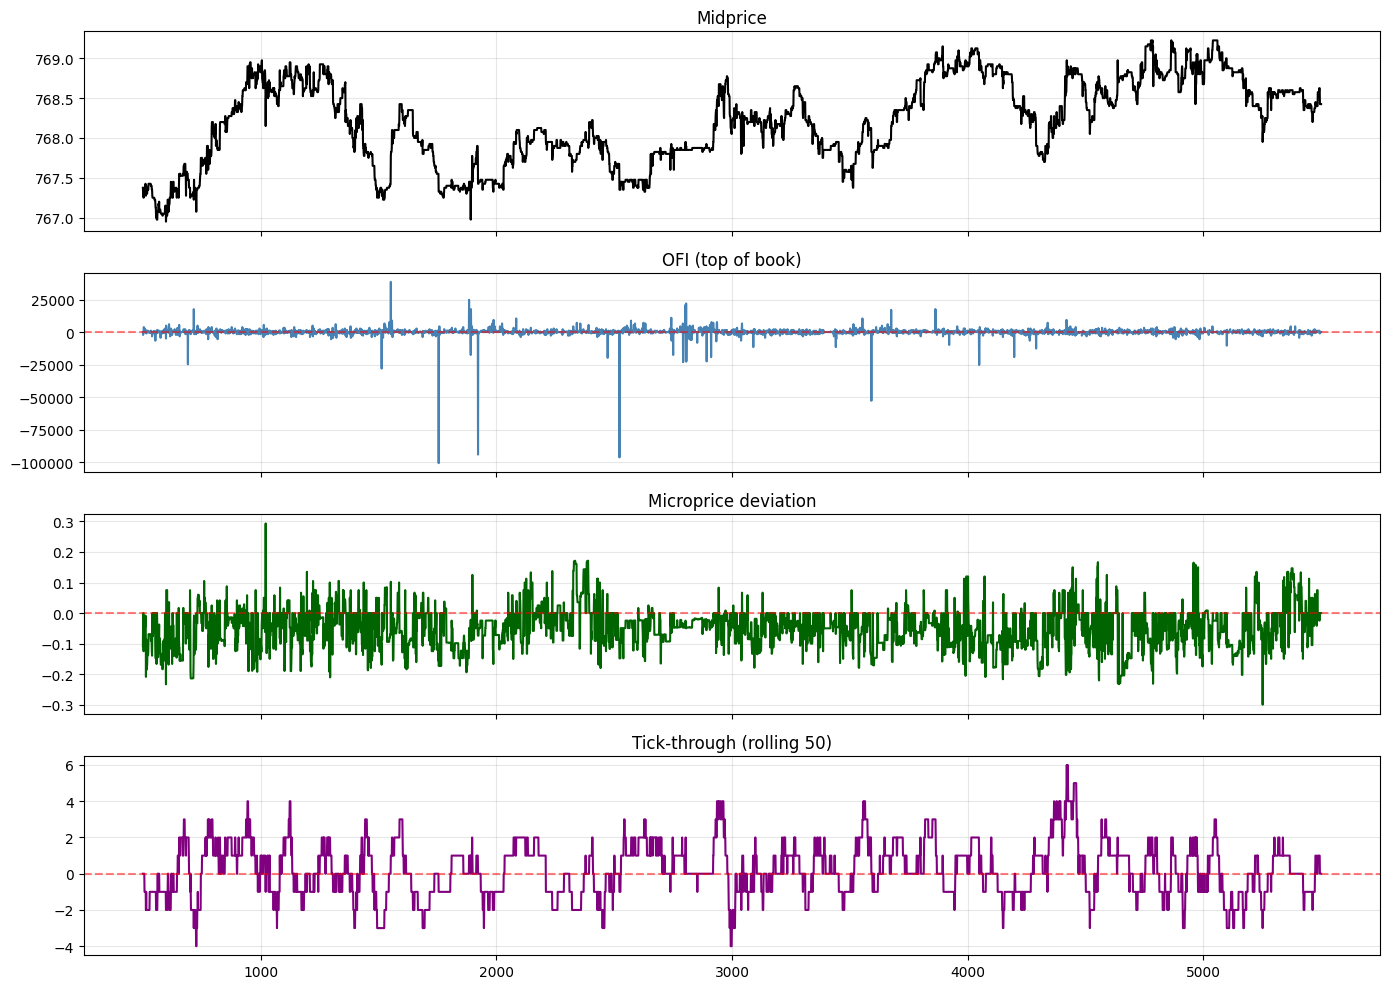

In [10]:
window_slice = slice(500, 5500)
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df["midprice"].iloc[window_slice], color="black")
axes[0].set_title("Midprice"); axes[0].grid(alpha=0.3)

axes[1].plot(df["ofi_l1"].iloc[window_slice], color="steelblue")
axes[1].axhline(0, color="red", linestyle="--", alpha=0.5)
axes[1].set_title("OFI (top of book)"); axes[1].grid(alpha=0.3)

axes[2].plot(df["micro_deviation"].iloc[window_slice], color="darkgreen")
axes[2].axhline(0, color="red", linestyle="--", alpha=0.5)
axes[2].set_title("Microprice deviation"); axes[2].grid(alpha=0.3)

axes[3].plot(df["tick_through_50"].iloc[window_slice], color="purple")
axes[3].axhline(0, color="red", linestyle="--", alpha=0.5)
axes[3].set_title("Tick-through (rolling 50)"); axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 - Cross-correlation between signals

If two signals are highly correlated, the composite won't gain much from including both.

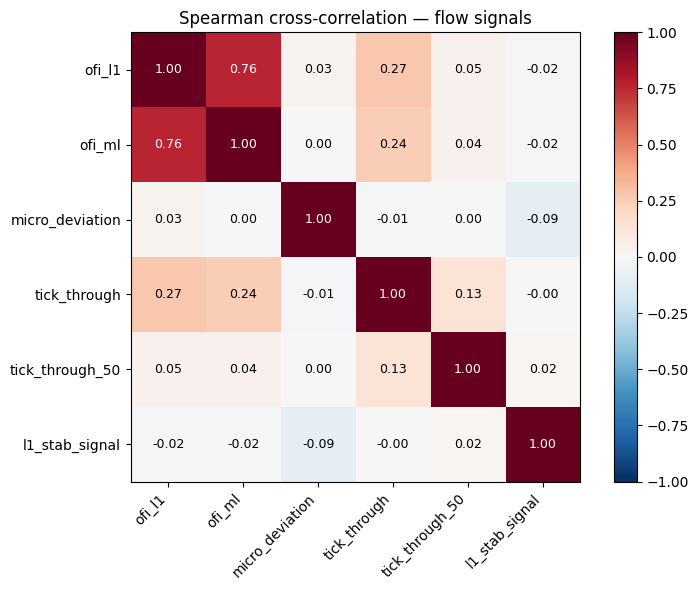

In [11]:
corr = df[FLOW_SIGNALS].dropna().corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FLOW_SIGNALS))); ax.set_xticklabels(FLOW_SIGNALS, rotation=45, ha="right")
ax.set_yticks(range(len(FLOW_SIGNALS))); ax.set_yticklabels(FLOW_SIGNALS)
for i in range(len(FLOW_SIGNALS)):
    for j in range(len(FLOW_SIGNALS)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i,j]) > 0.5 else "black", fontsize=9)
plt.colorbar(im, ax=ax)
plt.title("Spearman cross-correlation - flow signals"); plt.tight_layout(); plt.show()

## Section 4 - IC Analysis

Same methodology as `ic_analysis.ipynb`:
- Forward return: `midprice[t+h] - midprice[t]`
- IC: Spearman correlation between signal and forward return (per session)
- Aggregate: mean IC, ICIR (mean/std), pct_pos across all (symbol, date) pairs

In [12]:
HORIZONS = [1, 5, 10, 20, 50, 100, 200]

def compute_ic(signal, forward_return, min_obs=200):
    mask = ~(np.isnan(signal) | np.isnan(forward_return))
    if mask.sum() < min_obs:
        return np.nan
    sig = signal[mask]; ret = forward_return[mask]
    if sig.std() == 0 or ret.std() == 0:
        return np.nan
    return spearmanr(sig, ret)[0]

def ic_table_for_session(df, signals, horizons):
    mid = df["midprice"].to_numpy()
    rows = []
    for h in horizons:
        fwd = np.full(len(df), np.nan)
        fwd[:-h] = mid[h:] - mid[:-h]
        for sig in signals:
            rows.append({"signal": sig, "h": h,
                         "ic": compute_ic(df[sig].to_numpy(), fwd)})
    return pd.DataFrame(rows).pivot(index="signal", columns="h", values="ic")

### 4.1 - Single-session IC (HDFCBANK 2026-05-22)

Quick first look before running the full multi-session loop.

In [13]:
ic_single = ic_table_for_session(df, FLOW_SIGNALS, HORIZONS)
ic_single.round(4)

h,1,5,10,20,50,100,200
signal,,,,,,,
l1_stab_signal,-0.0152,-0.0305,-0.0395,-0.0454,-0.0327,-0.0292,-0.0326
micro_deviation,0.1236,0.1530,0.1418,0.1173,0.0783,0.0484,0.0116
ofi_l1,0.0065,0.0242,0.0227,0.0296,0.0294,0.0242,0.0198
ofi_ml,0.0104,0.0265,0.0280,0.0349,0.0326,0.0262,0.0192
tick_through,-0.0189,-0.0240,-0.0365,-0.0304,-0.0227,-0.0178,-0.0150
tick_through_50,-0.0052,-0.0175,-0.0223,-0.0216,-0.0034,-0.0153,-0.0239


### 4.2 - Full IC sweep across all sessions

Memory-safe: stream one session at a time, compute IC, discard the DataFrame, keep only the small IC records. Takes ~5 minutes on M1.

In [14]:
inventory, _ = _build_inventory()
print(f"Sessions to process: {len(inventory)}")

ic_records = []
for idx, row in inventory.iterrows():
    try:
        df_sess = load_depth(row["underlying"], row["date"],
                             session_filter=True, path=row["path"])
        df_sess = add_flow_features(df_sess)
        tab = ic_table_for_session(df_sess, FLOW_SIGNALS, HORIZONS)
        for sig in tab.index:
            for h in tab.columns:
                ic_records.append({
                    "underlying": row["underlying"],
                    "date":       row["date"],
                    "signal":     sig,
                    "h":          h,
                    "ic":         tab.loc[sig, h],
                })
        del df_sess  # explicit release
    except (FileNotFoundError, ValueError) as e:
        print(f"  SKIP {row['underlying']} {row['date']}: {e}")
        continue
    if idx % 10 == 0:
        print(f"  [{idx+1}/{len(inventory)}] {row['underlying']} {row['date']}")

ic_df = pd.DataFrame(ic_records)
print(f"\nIC records collected: {len(ic_df)}")
ic_df.head()

Sessions to process: 79
  [1/79] HDFCBANK 2026-04-24
  [11/79] HDFCBANK 2026-05-11
  [21/79] ICICIBANK 2026-04-24
  [31/79] ICICIBANK 2026-05-11
  [41/79] RELIANCE 2026-04-24
  [51/79] RELIANCE 2026-05-11
  SKIP RELIANCE 2026-05-20: Insufficient data for RELIANCE 2026-05-20: 12 session rows (minimum 50,000). File is likely corrupt or incomplete.
  [61/79] TCS 2026-04-24
  [71/79] TCS 2026-05-11

IC records collected: 3276


,underlying,date,signal,h,ic
0,HDFCBANK,2026-04-24,l1_stab_signal,1,-0.0118
1,HDFCBANK,2026-04-24,l1_stab_signal,5,-0.0146
2,HDFCBANK,2026-04-24,l1_stab_signal,10,-0.0109
3,HDFCBANK,2026-04-24,l1_stab_signal,20,-0.0196
4,HDFCBANK,2026-04-24,l1_stab_signal,50,-0.0259


In [15]:
# Cache so we don't have to re-run the long loop
ic_df.to_csv("/Users/krishhiv/Desktop/argus-alpha-research/research/notebooks/_cache_flow_ic.csv", index=False)
print("Cached.")

Cached.


### 4.3 - Summary statistics

**mean IC** - average per-session predictive power.  
**ICIR** = mean(IC) / std(IC) - Sharpe-like reliability across sessions.  
**pct_pos** - fraction of sessions where IC was positive.

**Targets:** ICIR ≥ 3.0 for a reliable signal, mean IC ≥ 0.10 for cost-overcoming potential.

In [16]:
def summarize(ic_df):
    grp = ic_df.dropna(subset=["ic"]).groupby(["signal", "h"])
    summary = grp.agg(
        mean_ic = ("ic", "mean"),
        std_ic  = ("ic", "std"),
        icir    = ("ic", lambda x: x.mean() / (x.std() + 1e-9)),
        pct_pos = ("ic", lambda x: (x > 0).mean()),
        n       = ("ic", "count"),
    ).round(4)
    return summary

flow_summary = summarize(ic_df)
flow_summary

mean_ic  std_ic    icir  pct_pos   n
signal          h                                        
l1_stab_signal  1    -0.0156  0.0076 -2.0413   0.0128  78
                5    -0.0313  0.0144 -2.1803   0.0000  78
                10   -0.0414  0.0185 -2.2347   0.0000  78
                20   -0.0523  0.0199 -2.6350   0.0000  78
                50   -0.0550  0.0227 -2.4225   0.0000  78
                100  -0.0517  0.0234 -2.2146   0.0000  78
                200  -0.0420  0.0211 -1.9917   0.0128  78
micro_deviation 1     0.1089  0.0157  6.9230   1.0000  78
                5     0.1445  0.0263  5.5043   1.0000  78
                10    0.1468  0.0307  4.7760   1.0000  78
                20    0.1362  0.0332  4.1034   1.0000  78
                50    0.1009  0.0322  3.1332   1.0000  78
                100   0.0698  0.0304  2.2977   1.0000  78
                200   0.0444  0.0293  1.5188   0.9615  78
ofi_l1          1     0.0052  0.0221  0.2340   0.6923  78
                5     0.0216  0.0182  1.1895   0.8846  78
                10    0.0278  0.0171  1.6243   0.9231  78
                20    0.0317  0.0160  1.9852   0.9615  78
                50    0.0297  0.0140  2.1231   0.9872  78
                100   0.0234  0.0117  2.0058   0.9615  78
                200   0.0167  0.0086  1.9336   0.9744  78
ofi_ml          1     0.0135  0.0212  0.6383   0.7692  78
                5     0.0318  0.0184  1.7310   0.9615  78
                10    0.0372  0.0172  2.1627   0.9744  78
                20    0.0395  0.0159  2.4920   1.0000  78
                50    0.0362  0.0135  2.6786   1.0000  78
                100   0.0285  0.0113  2.5261   1.0000  78
                200   0.0203  0.0084  2.4095   0.9872  78
tick_through    1    -0.0211  0.0186 -1.1337   0.1026  78
                5    -0.0222  0.0170 -1.3122   0.0769  78
                10   -0.0214  0.0162 -1.3177   0.0513  78
                20   -0.0178  0.0158 -1.1271   0.1154  78
                50   -0.0123  0.0142 -0.8666   0.2051  78
                100  -0.0092  0.0117 -0.7832   0.2051  78
                200  -0.0065  0.0088 -0.7381   0.2179  78
tick_through_50 1     0.0008  0.0114  0.0677   0.5513  78
                5     0.0006  0.0238  0.0258   0.5000  78
                10   -0.0007  0.0311 -0.0235   0.4615  78
                20   -0.0031  0.0382 -0.0806   0.4487  78
                50   -0.0071  0.0437 -0.1632   0.4359  78
                100  -0.0084  0.0431 -0.1952   0.4231  78
                200  -0.0103  0.0339 -0.3025   0.3846  78

### 4.4 - Visualize IC by horizon

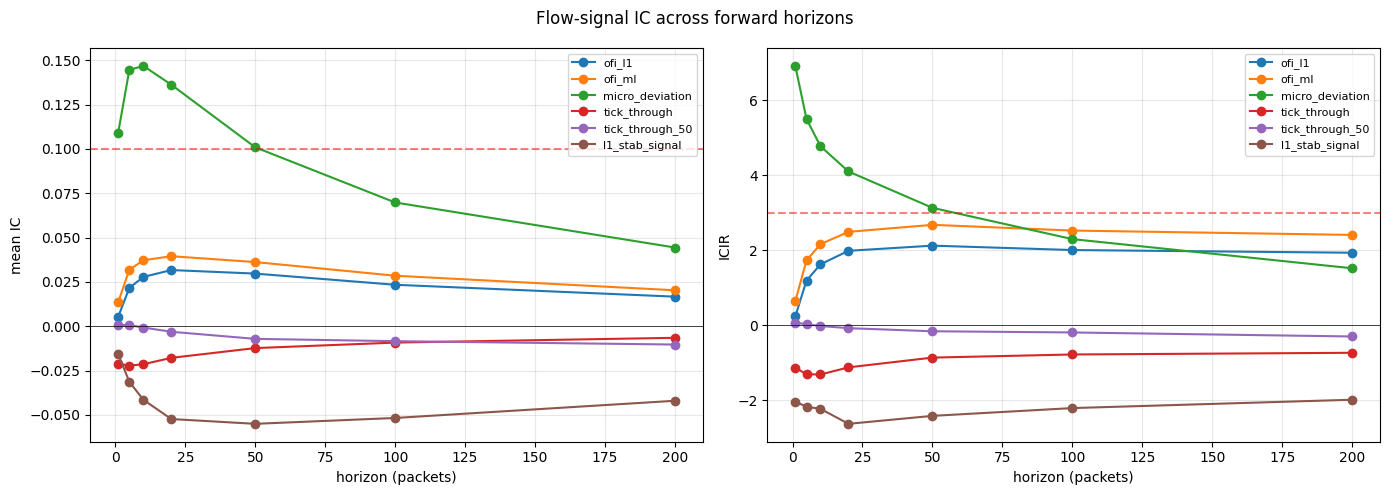

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for sig in FLOW_SIGNALS:
    sub = flow_summary.loc[sig]
    ax1.plot(sub.index, sub["mean_ic"], marker="o", label=sig)
    ax2.plot(sub.index, sub["icir"],   marker="o", label=sig)

for ax, ylabel in [(ax1, "mean IC"), (ax2, "ICIR")]:
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xlabel("horizon (packets)"); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax1.axhline(0.10, color="red", linestyle="--", alpha=0.5, label="target 0.10")
ax2.axhline(3.0,  color="red", linestyle="--", alpha=0.5, label="target 3.0")
plt.suptitle("Flow-signal IC across forward horizons"); plt.tight_layout(); plt.show()

## Section 5 - Comparison with existing A5/A6 signals

Run the same IC analysis on A5/A6 signals using the SAME methodology and SAME forward returns, so the comparison is apples-to-apples.

In [18]:
OLD_SIGNALS = ["a5_condensation_signal", "a6_bid_shallowing", "a6_ask_shallowing"]
_, prev_calib = _build_inventory()

old_records = []
for idx, row in inventory.iterrows():
    key = (row["underlying"], row["date"])
    p_calib = prev_calib.get(key)
    if p_calib is None:
        continue
    try:
        df_o = load_depth(row["underlying"], row["date"], session_filter=True, path=row["path"])
        df_o = add_all_features(df_o, size_threshold=p_calib, order_size=p_calib*10)
        tab = ic_table_for_session(df_o, OLD_SIGNALS, HORIZONS)
        for sig in tab.index:
            for h in tab.columns:
                old_records.append({"underlying": row["underlying"], "date": row["date"],
                                    "signal": sig, "h": h, "ic": tab.loc[sig, h]})
        del df_o
    except (FileNotFoundError, ValueError):
        continue
    if idx % 10 == 0:
        print(f"  [{idx+1}/{len(inventory)}] {row['underlying']} {row['date']}")

old_ic_df = pd.DataFrame(old_records)
old_summary = summarize(old_ic_df)
old_summary

  [11/79] HDFCBANK 2026-05-11
  [31/79] ICICIBANK 2026-05-11
  [51/79] RELIANCE 2026-05-11
  [71/79] TCS 2026-05-11


mean_ic  std_ic    icir  pct_pos   n
signal                 h                                        
a5_condensation_signal 1     0.0357  0.0122  2.9274   1.0000  73
                       5     0.0500  0.0217  2.3100   0.9863  73
                       10    0.0533  0.0247  2.1528   0.9589  73
                       20    0.0530  0.0284  1.8669   0.9589  73
                       50    0.0422  0.0261  1.6179   0.9178  73
                       100   0.0328  0.0201  1.6267   0.9452  73
                       200   0.0239  0.0159  1.5094   0.9041  73
a6_ask_shallowing      1     0.0366  0.0106  3.4610   1.0000  73
                       5     0.0560  0.0177  3.1614   1.0000  73
                       10    0.0613  0.0203  3.0154   1.0000  73
                       20    0.0637  0.0231  2.7633   1.0000  73
                       50    0.0529  0.0200  2.6386   1.0000  73
                       100   0.0420  0.0159  2.6432   1.0000  73
                       200   0.0308  0.0129  2.3809   1.0000  73
a6_bid_shallowing      1    -0.0428  0.0122 -3.5044   0.0000  73
                       5    -0.0626  0.0189 -3.3141   0.0000  73
                       10   -0.0676  0.0214 -3.1618   0.0000  73
                       20   -0.0677  0.0234 -2.8875   0.0000  73
                       50   -0.0581  0.0208 -2.7938   0.0137  73
                       100  -0.0438  0.0169 -2.5931   0.0137  73
                       200  -0.0327  0.0132 -2.4836   0.0000  73

### 5.1 - Side-by-side ICIR comparison

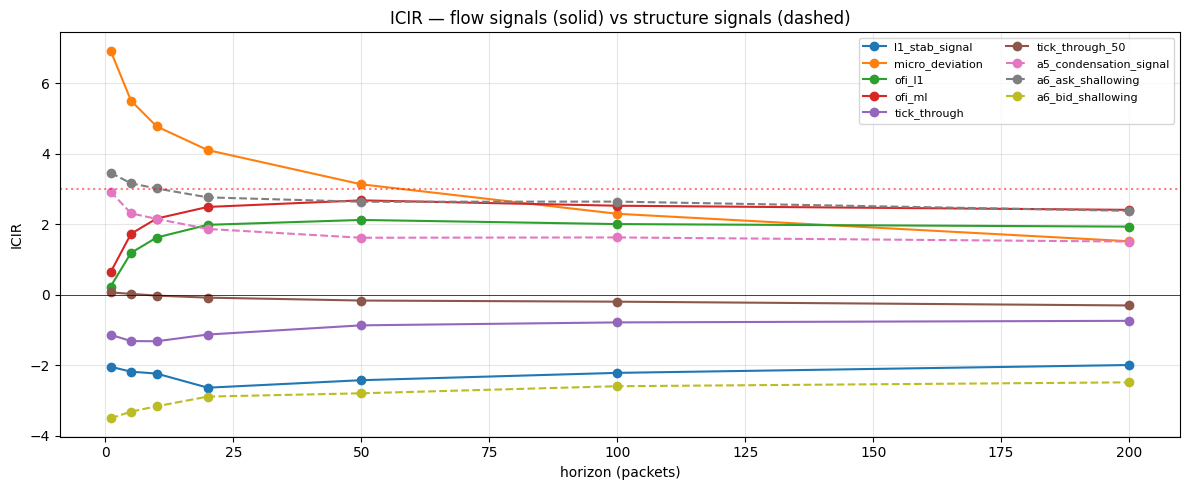

In [19]:
combined = pd.concat([
    flow_summary["icir"].rename("icir").reset_index().assign(family="flow"),
    old_summary["icir"].rename("icir").reset_index().assign(family="structure"),
])

fig, ax = plt.subplots(figsize=(12, 5))
for sig in combined["signal"].unique():
    sub = combined[combined["signal"] == sig]
    style = "-" if sub["family"].iloc[0] == "flow" else "--"
    ax.plot(sub["h"], sub["icir"], style, marker="o", label=sig)
ax.axhline(0, color="black", linewidth=0.5)
ax.axhline(3.0, color="red", linestyle=":", alpha=0.5)
ax.set_xlabel("horizon (packets)"); ax.set_ylabel("ICIR")
ax.set_title("ICIR - flow signals (solid) vs structure signals (dashed)")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Section 6 - Composite Construction

Pick the top 2-3 signals by ICIR at the most actionable horizon (likely h=5-20 for flow signals). Build a rolling-z-scored, EMA-smoothed composite and measure its IC.

In [20]:
# Inspect which signals are strongest at h=10 (typical actionable horizon)
h_pick = 10
combo_ranked = pd.concat([
    flow_summary.xs(h_pick, level="h")[["mean_ic", "icir", "pct_pos"]],
    old_summary.xs(h_pick, level="h")[["mean_ic", "icir", "pct_pos"]],
]).sort_values("icir", ascending=False)
print(f"Signal ranking at h={h_pick}:")
combo_ranked

Signal ranking at h=10:


,mean_ic,icir,pct_pos
signal,,,
micro_deviation,0.1468,4.7760,1.0000
a6_ask_shallowing,0.0613,3.0154,1.0000
ofi_ml,0.0372,2.1627,0.9744
a5_condensation_signal,0.0533,2.1528,0.9589
ofi_l1,0.0278,1.6243,0.9231
tick_through_50,-0.0007,-0.0235,0.4615
tick_through,-0.0214,-1.3177,0.0513
l1_stab_signal,-0.0414,-2.2347,0.0000
a6_bid_shallowing,-0.0676,-3.1618,0.0000


In [21]:
# Build a composite from the top 3 by ICIR
ZSCORE_WINDOW = 100
EMA_SPAN      = 100

def rolling_z(s, w):
    mu  = s.rolling(w, min_periods=20).mean()
    sd  = s.rolling(w, min_periods=20).std()
    return (s - mu) / (sd + 1e-9)

def build_flow_composite(df, signals_to_combine):
    raw = sum(rolling_z(df[s], ZSCORE_WINDOW) for s in signals_to_combine)
    return raw.ewm(span=EMA_SPAN, adjust=False).mean()

# Top 3 by ICIR at h=10 (read off the table above, edit this list manually if desired)
top3 = combo_ranked.head(3).index.tolist()
print(f"Composite ingredients: {top3}")

Composite ingredients: ['micro_deviation', 'a6_ask_shallowing', 'ofi_ml']


In [22]:
# Compute IC of the new composite across all sessions (and existing composite_eq for reference)
composite_records = []
for idx, row in inventory.iterrows():
    key = (row["underlying"], row["date"])
    p_calib = prev_calib.get(key)
    if p_calib is None:
        continue
    try:
        df_c = load_depth(row["underlying"], row["date"], session_filter=True, path=row["path"])
        df_c = add_flow_features(df_c)
        df_c = add_all_features(df_c, size_threshold=p_calib, order_size=p_calib*10)

        # New flow composite
        df_c["flow_composite"] = build_flow_composite(df_c, top3)

        tab = ic_table_for_session(df_c, ["flow_composite", "composite_eq"], HORIZONS)
        for sig in tab.index:
            for h in tab.columns:
                composite_records.append({"underlying": row["underlying"], "date": row["date"],
                                          "signal": sig, "h": h, "ic": tab.loc[sig, h]})
        del df_c
    except (FileNotFoundError, ValueError):
        continue
    if idx % 10 == 0:
        print(f"  [{idx+1}/{len(inventory)}]")

comp_df = pd.DataFrame(composite_records)
summarize(comp_df)

  [11/79]
  [31/79]
  [51/79]
  [71/79]


mean_ic  std_ic   icir  pct_pos   n
signal         h                                       
composite_eq   1     0.0248  0.0086 2.9050   1.0000  73
               5     0.0488  0.0181 2.6930   1.0000  73
               10    0.0603  0.0235 2.5699   1.0000  73
               20    0.0662  0.0280 2.3654   1.0000  73
               50    0.0580  0.0287 2.0249   0.9589  73
               100   0.0445  0.0227 1.9643   0.9589  73
               200   0.0346  0.0175 1.9765   0.9863  73
flow_composite 1     0.0364  0.0079 4.6195   1.0000  74
               5     0.0707  0.0164 4.3234   1.0000  74
               10    0.0854  0.0211 4.0395   1.0000  74
               20    0.0919  0.0250 3.6812   1.0000  74
               50    0.0801  0.0283 2.8288   1.0000  74
               100   0.0623  0.0251 2.4823   0.9865  74
               200   0.0481  0.0228 2.1109   0.9865  74

## Section 7 - Decision

**Read off the final composite ICIR and mean IC at h=5, 10, 20.**

- If ICIR ≥ 3.0 AND mean IC ≥ 0.15 at any of those horizons → promote the new flow signals into `depth_features.py` and run the walkforward backtester.
- If 0.10 ≤ mean IC < 0.15 → try a different signal weighting or longer EMA span, retest.
- If mean IC < 0.10 → flow signals alone aren't enough on this data either. Pivot to A7 stat arb.

**Reminder of the cost barrier:** at NSE futures costs (₹185 break-even directional edge per trade), we need expected gross PnL per trade ≥ ₹185. With mean IC ≈ 0.15 and 200-packet σ ≈ 3 ticks, expected gross at hold=200 is roughly `IC × σ × lot_value × tick_size = 0.15 × 3 × 550 × 0.05 ≈ ₹12`. We'd need IC ≈ 2.0 to hit break-even at h=200, which is impossible. Practically we need either:
1. **IC ≥ 0.25 at h=5-20** (very short hold, low σ but enough IC to amplify), OR
2. **Discrete event signals** (tick-through) where the entry only fires when the move has already begun.

This notebook tells us which path is viable.